<font color='blue'>  **6 _______________________ 2D  _______________** </font> <br>

In [1]:
from Grid import Grid  ; from ScalarCoeffs import ScalarCoeffs ; from BoundaryConditions import BoundaryLocation, DirichletBc, NeumannBc ; from LinearSolver import solve 
from Models import DiffusionModel, SurfaceConvectionModel, FirstOrderTransientModel, PressureForceModel , AdvectingVelocityModel , MassConservationEquation, UpwindAdvectionModel
%matplotlib inline
import matplotlib.pyplot as plt ; import numpy as np  ; from numpy.linalg import norm   

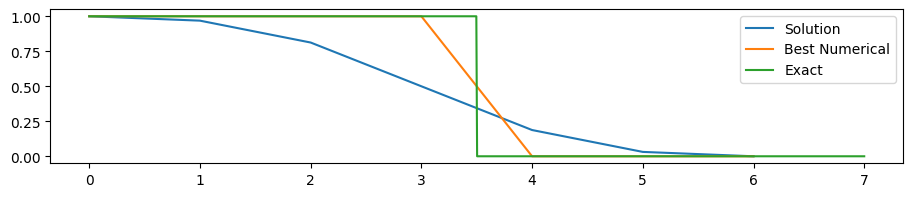

In [2]:
phi = np.zeros((7, 7))  ; phi[:,0] = 1
for j in reversed(range ( phi.shape[0]-1)):
    for i in range(1     ,phi.shape[1]   ):  phi[j,i] = 0.5*phi[j,i-1] + 0.5*phi[j+1,i]      #print(phi)

sol=np.diag(phi)  ;x=np.array([_ for _ in range(sol.size)])  ;best=np.where(x < x.size/2.0, 1, 0)   ;x_exact=np.linspace(0,x.size,1000)  ;exact=np.where(x_exact < x.size/2.0,1,0)
plt.figure(figsize=(11, 2)) 
plt.plot(x, sol, label='Solution') ; plt.plot(x, best, label='Best Numerical') ; plt.plot(x_exact, exact, label='Exact') ; plt.legend() ; plt.show()

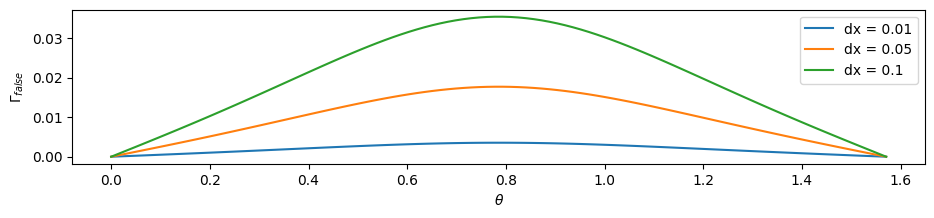

theta: 100 1.57 gamma: 0.0 0.04


In [3]:
delta = [0.01, 0.05, 0.1]       ; theta = np.linspace(0, np.pi/2, 100)
plt.figure(figsize=(11, 2))
for d in delta:
    gamma = d*d*np.sin(2*theta)/4/(d*np.power(np.sin(theta), 3) + d*np.power(np.cos(theta),3))
    plt.plot(theta, gamma, label="dx = " + str(d))
plt.xlabel(r"$\theta$") ; plt.ylabel(r"$\Gamma_{false}$") ; plt.legend() ; plt.show()   ; print('theta:',len(theta), round(theta.max(),2),'gamma:',gamma.min(),round(gamma.max(),2))